In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import requests
import pandas as pd
import os
import json

resource_id = "4a46d93f-9fd9-4cce-8952-424918edeafe"

api_url = "https://donnees.montreal.ca/api/3/action/datastore_search"

if not os.path.exists('data'):
    os.makedirs('data')

params = {
    'resource_id': resource_id,
    'filters': json.dumps({"DESCRIPTION_GROUPE": ["INCENDIE", "AUTREFEU"]}),
    'limit': 1000000 
}

try:
    print(f"Fetching data...")
    response = requests.get(api_url, params=params)
    response.raise_for_status()
    
    data = response.json()
    records = data['result']['records']
    
    if records:
        df = pd.DataFrame(records)
        file_path = 'data/interventions_incendie_dechets.csv'
        df.to_csv(file_path, index=False, encoding='utf-8-sig')
        print(f"Success! Saved {len(df)} rows to {file_path}")
    else:
        print("No records found. Check if the 'DESCRIPTION_GROUPE' values match exactly.")

except Exception as e:
    print(f"An error occurred: {e}")

Fetching data...
Success! Saved 20098 rows to data/interventions_incendie_dechets.csv


          _id  INCIDENT_NBR   CREATION_DATE_TIME         INCIDENT_TYPE_DESC  \
0           1          4579  2022-01-16T09:45:45            Feu / 4e Alerte   
1           6         67504  2022-08-02T21:15:46          Feu de cuisinière   
2          23         98264  2021-11-25T08:47:33  Feu de véhicule extérieur   
3          58         57586  2022-07-05T16:43:44             10-22 avec feu   
4          78         29054  2022-04-12T19:35:12             Déchets en feu   
...       ...           ...                  ...                        ...   
20093  539120         57164  2020-09-10T18:54:33             Feu de champ *   
20094  539125         35965  2020-06-21T17:27:43             Feu de champ *   
20095  539170         42948  2021-06-02T21:39:11             Déchets en feu   
20096  539171         43692  2021-06-05T03:38:13             Feu de champ *   
20097  539178         81896  2020-12-07T10:18:06   Feu d'auto (voie rapide)   

      DESCRIPTION_GROUPE  CASERNE NOM_VILLE  \
0   

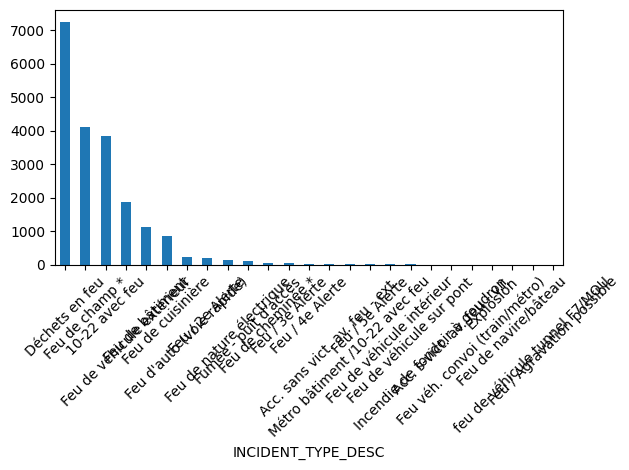

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/interventions_incendie_dechets.csv')
print(df)
df_counts = df.groupby("INCIDENT_TYPE_DESC")["INCIDENT_NBR"].count().reset_index()
df_counts = df_counts.sort_values(by="INCIDENT_NBR", ascending=False)

df_counts.plot.bar(x="INCIDENT_TYPE_DESC", y="INCIDENT_NBR", rot=45, legend=False)

plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
import plotly.express as px
df = pd.read_csv('data/interventions_incendie_dechets.csv')
df_grouped = df.groupby(['NOM_ARROND', 'INCIDENT_TYPE_DESC']).size().reset_index(name='COUNT')

df_grouped = df_grouped.sort_values(by='COUNT', ascending=False)

fig = px.bar(
    df_grouped, 
    x="NOM_ARROND", 
    y="COUNT", 
    color="INCIDENT_TYPE_DESC",
    title="Fire Incidents by Arrondissement and Type",
    labels={"COUNT": "Number of Incidents", "NOM_ARROND": "Neighborhood"},
    template="plotly_white"
)
fig.update_layout(barmode='stack', xaxis={'categoryorder':'total descending'})

fig.show(renderer="browser")

In [ ]:
import pandas as pd
import plotly.express as px

df = pd.read_csv('data/interventions_incendie_dechets.csv')
top_10_types = df['INCIDENT_TYPE_DESC'].value_counts().nlargest(5).index

df['TYPE_GROUPED'] = df['INCIDENT_TYPE_DESC'].apply(lambda x: x if x in top_10_types else 'Others')
df_grouped = df.groupby(['NOM_ARROND', 'TYPE_GROUPED']).size().reset_index(name='COUNT')

fig = px.bar(
    df_grouped, 
    x="NOM_ARROND", 
    y="COUNT", 
    color="TYPE_GROUPED",
    title="Fire Incidents by Arrondissement (Top 10 + Others)",
    labels={"COUNT": "Number of Incidents", "NOM_ARROND": "Arrondissement", "TYPE_GROUPED": "Incident Type"},
    template="plotly_white",
    category_orders={"TYPE_GROUPED": list(top_10_types) + ["Others"]}
)

fig.update_layout(
    barmode='stack', 
    xaxis={'categoryorder':'total descending'},
    legend_title_text='Incident Types'
)
fig.show(renderer="browser")


In [ ]:
import pandas as pd
import plotly.express as px

df = pd.read_csv('data/interventions_incendie_dechets.csv')
df = df[df['NOM_ARROND'] != 'Indéterminé']

top_10_types = df['INCIDENT_TYPE_DESC'].value_counts().nlargest(5).index

df['TYPE_GROUPE'] = df['INCIDENT_TYPE_DESC'].apply(lambda x: x if x in top_10_types else 'Autres')
df_grouped = df.groupby(['NOM_ARROND', 'TYPE_GROUPE']).size().reset_index(name='NOMBRE')

fig = px.bar(
    df_grouped, 
    x="NOM_ARROND", 
    y="NOMBRE", 
    color="TYPE_GROUPE",
    title="Incendies par arrondissement et type (Top 10 + Autres)",
    labels={
        "NOMBRE": "Nombre d'incidents", 
        "NOM_ARROND": "Arrondissement", 
        "TYPE_GROUPE": "Type d'incident"
    },
    template="plotly_white",
    category_orders={"TYPE_GROUPE": list(top_10_types) + ["Autres"]}
)

fig.update_layout(
    barmode='stack', 
    xaxis={'categoryorder':'total descending'},
    legend_title_text='Types d\'incidents'
)

fig.show(renderer="browser")


In [ ]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import math

df = pd.read_csv('data/interventions_incendie_dechets.csv')
COL_ARROND = 'NOM_ARROND'
COL_UNITES = 'NOMBRE_UNITES'

df = df[df[COL_ARROND] != 'Indéterminé'].copy()
df[COL_UNITES] = pd.to_numeric(df[COL_UNITES], errors='coerce').fillna(0)

def categoriser_gravite(unites):
    if unites <= 1: return 'Mineure <= 1 unités'
    elif unites <= 5: return 'Standard <= 5 unités'
    elif unites <= 15: return 'Confirmée  <= 15 unités'
    elif unites <= 30: return 'Majeure <= 30 unités'
    else: return 'Critique > 30 unités'

df['Gravité'] = df[COL_UNITES].apply(categoriser_gravite)

tous_arrond = sorted(df[COL_ARROND].unique())
n_arrond = len(tous_arrond)
n_cols = 4  
n_rows = math.ceil(n_arrond / n_cols)

categories = ['Mineure <= 1 unités', 'Standard <= 5 unités', 'Confirmée  <= 15 unités', 'Majeure <= 30 unités', 'Critique > 30 unités']
colors = ["#FFCACA", "#FF7070", "#FF0000", "#990000", "#330000"]

fig = make_subplots(
    rows=n_rows, cols=n_cols, 
    subplot_titles=tous_arrond,
    horizontal_spacing=0.05, 
    vertical_spacing=0.12  
)
for cat, color in zip(categories, colors):
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(size=12, color=color, symbol='square'),
        name=cat, showlegend=True
    ))

for i, arrond in enumerate(tous_arrond):
    row, col = (i // n_cols) + 1, (i % n_cols) + 1
    counts = df[df[COL_ARROND] == arrond]['Gravité'].value_counts(normalize=True) * 100
    
    waffle_list = []
    for cat in reversed(categories):
        waffle_list.extend([cat] * int(round(counts.get(cat, 0))))
    
    while len(waffle_list) < 100: waffle_list.append('Mineure <= 1 unités')
    waffle_list = waffle_list[:100]
    z_matrix = np.array(waffle_list).reshape(10, 10)
    
    heatmap = go.Heatmap(
        z=[[categories.index(c) for c in r] for r in z_matrix],
        text=z_matrix, hoverinfo="text",
        colorscale=[[i/4, colors[i]] for i in range(5)],
        showscale=False, xgap=1, ygap=1
    )
    fig.add_trace(heatmap, row=row, col=col)

fig.update_layout(
    title_text="Gravité des Interventions par Arrondissement",
    height=350 * n_rows, 
    width=1300,
    template="plotly_white",
    margin=dict(t=100, b=50, l=50, r=150),
    legend=dict(title="Gravité", x=1.02, y=1)
)

fig.update_annotations(font_size=12)

fig.update_xaxes(showticklabels=False, showgrid=False, zeroline=False)
fig.update_yaxes(showticklabels=False, showgrid=False, zeroline=False, autorange="reversed")

fig.write_html("waffle_montreal_spaced.html")
fig.show(renderer="browser")

In [ ]:
import pandas as pd
import plotly.express as px

df = pd.read_csv('data/interventions_incendie_dechets.csv')
COL_TYPE = 'INCIDENT_TYPE_DESC'
COL_UNITES = 'NOMBRE_UNITES'

df[COL_UNITES] = pd.to_numeric(df[COL_UNITES], errors='coerce').fillna(0)
top_types = df[COL_TYPE].value_counts().nlargest(15).index
df_filtered = df[df[COL_TYPE].isin(top_types)]

fig = px.box(
    df_filtered, 
    x=COL_UNITES, 
    y=COL_TYPE, 
    color=COL_TYPE,
    title="Distribution des unités mobilisées par type d'incident",
    labels={COL_UNITES: "Nombre d'unités mobilisées", COL_TYPE: "Type d'incident"},
    template="plotly_white"
)
fig.update_layout(
    showlegend=False,
    xaxis_title="Nombre d'unités (Intensité)",
    yaxis={'categoryorder':'median ascending'}
)

fig.show(renderer="browser")